# Codificación de variables categóricas o cualitativas

Los modelos de aprendizaje de máquina no pueden procesar valores que no sean numéricos. En particular, las variables categóricas, esto es, aquellas que solo pueden tomar un número finito de valores, que en este contexto se conocen como **clases**, **categorías** o **etiquetas**, suelen ser cadenas de texto. Es por esto que es necesario procesarlas para convertir estas cadenas de texto en números. Este proceso se conoce como **codificación**.

Existen 2 procedimientos para codificar:

- Sí los valores que pueden tomar las variables no tienen orden, se llaman variables nominales y se codifican con variables indicadoras.
- Sí los valores que pueden tomar las variables tienen orden, se llaman variables ordinales y se codifican con codificación ordinal.

Estos dos procedimientos pueden hacerse tanto en Pandas como en Scikit Learn.

Las variables nominales no tienen orden y las ordinales si

Las ordinales tienen un orden establecido, pueden tener una gerarquía también 

Codificar se refiere pasar de texto a número

In [36]:
from pathlib import Path

DATA_DIR = Path().resolve().parent / "data" / "raw"
file_name = "adult.data"
file_path = DATA_DIR / file_name

In [37]:
import pandas as pd

df = pd.read_csv(
    file_path,
    header=None,
    na_values= ' ?',
    names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
             'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
             'hours-per-week', 'native-country', 'income']
    )

df = df.dropna() #Elimina filas con datos nulos, pero se pierden datos importantes
df.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
11288,22,Private,315524,Some-college,10,Never-married,Adm-clerical,Own-child,Black,Male,0,0,30,Dominican-Republic,<=50K
12137,69,Private,177374,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,1848,0,12,United-States,<=50K
7059,45,Private,281565,HS-grad,9,Widowed,Other-service,Other-relative,Asian-Pac-Islander,Female,0,0,50,South,<=50K
8283,38,Private,326886,Assoc-voc,11,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
14668,30,Private,185027,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,>50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   fnlwgt          30162 non-null  int64 
 3   education       30162 non-null  object
 4   education-num   30162 non-null  int64 
 5   marital-status  30162 non-null  object
 6   occupation      30162 non-null  object
 7   relationship    30162 non-null  object
 8   race            30162 non-null  object
 9   sex             30162 non-null  object
 10  capital-gain    30162 non-null  int64 
 11  capital-loss    30162 non-null  int64 
 12  hours-per-week  30162 non-null  int64 
 13  native-country  30162 non-null  object
 14  income          30162 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe(include='object').T #Permite ver estadísticas de variables categóricas

,count,unique,top,freq
workclass,30162,7,Private,22286
education,30162,16,HS-grad,9840
marital-status,30162,7,Married-civ-spouse,14065
occupation,30162,14,Prof-specialty,4038
relationship,30162,6,Husband,12463
race,30162,5,White,25933
sex,30162,2,Male,20380
native-country,30162,41,United-States,27504
income,30162,2,<=50K,22654


In [7]:
df['workclass'].unique() #Muestra los valores únicos de la columna workclass

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' Self-emp-inc', ' Without-pay'], dtype=object)

# Variables ordinales

Las variables ordinales son variables *cualitativas* cuyas *categorías* o *etiquetas* tienen un *orden* o *jerarquía* inherente entre sí.

Ejemplo de variables ordinales son:

- Nivel de educación (primaria, secundaria, universitaria)
- Escala de satisfacción (muy insatisfecho, insatisfecho, neutral, satisfecho, muy satisfecho)
- Clase social (baja, media, alta)
- Grado de acuerdo con una afirmación (totalmente en desacuerdo, en desacuerdo, neutral, de acuerdo, totalmente de acuerdo)

Están variables deben codificarse respetando el orden entre sus categorías.

En Pandas existen varios métodos para codificar variables ordinales:
- Usando las funciones `map` o `replace`
- Usando la función `Categorical`

Vamos a ver los métodos en acción. Para eso vamos a suponer que las categorías de la variable **marital-status** tienen el siguiente orden de menor a mayor:  'Never-married', ' Married-civ-spouse', ' Divorced', ' Married-spouse-absent', ' Separated', ' Married-AF-spouse', ' Widowed'.

Con `map` está variable se codificaría así:

.map sirve para cambiar una variables tipo objeto a una variable categorica

In [9]:
df['marital-status-map'] = df['marital-status'].map(
    {' Never-married': 0, ' Married-civ-spouse': 1, ' Divorced': 2,
     ' Married-spouse-absent': 3, ' Separated': 4, ' Married-AF-spouse': 5, ' Widowed': 6}
    )

df[['marital-status', 'marital-status-map']].head(10)

,marital-status,marital-status-map
0,Never-married,0
1,Married-civ-spouse,1
2,Divorced,2
3,Married-civ-spouse,1
4,Married-civ-spouse,1
5,Married-civ-spouse,1
6,Married-spouse-absent,3
7,Married-civ-spouse,1
8,Never-married,0
9,Married-civ-spouse,1


Con `Categorical`se codificaría así:

In [12]:
df['marital-status-cat'] = pd.Categorical(
    df['marital-status'],
    categories=[' Never-married', ' Married-civ-spouse', ' Divorced', ' Married-spouse-absent',
                ' Separated', ' Married-AF-spouse', ' Widowed'], ordered=True).codes

df[['marital-status', 'marital-status-cat']].head(10)


,marital-status,marital-status-cat
0,Never-married,0
1,Married-civ-spouse,1
2,Divorced,2
3,Married-civ-spouse,1
4,Married-civ-spouse,1
5,Married-civ-spouse,1
6,Married-spouse-absent,3
7,Married-civ-spouse,1
8,Never-married,0
9,Married-civ-spouse,1


In [14]:
df['marital-status-cat-2'] = pd.Categorical(
    df['marital-status'],
    categories=[' Never-married', ' Married-civ-spouse', ' Divorced', ' Married-spouse-absent',
                ' Separated', ' Married-AF-spouse', ' Widowed'], ordered=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   age                   30162 non-null  int64   
 1   workclass             30162 non-null  object  
 2   fnlwgt                30162 non-null  int64   
 3   education             30162 non-null  object  
 4   education-num         30162 non-null  int64   
 5   marital-status        30162 non-null  object  
 6   occupation            30162 non-null  object  
 7   relationship          30162 non-null  object  
 8   race                  30162 non-null  object  
 9   sex                   30162 non-null  object  
 10  capital-gain          30162 non-null  int64   
 11  capital-loss          30162 non-null  int64   
 12  hours-per-week        30162 non-null  int64   
 13  native-country        30162 non-null  object  
 14  income                30162 non-null  object  
 15  marital

También puede usarse la función `OrdinalEncoder` de `Scikit Learn` para codificar variables ordinales.

OrdinalEncoder es un método para preprocesar datos, codifica variables categoricas

Se les llama transformadores

In [16]:
from sklearn.preprocessing import OrdinalEncoder

# Orden de las categorías
orden = [' Never-married', ' Married-civ-spouse', ' Divorced', ' Married-spouse-absent', ' Separated', ' Married-AF-spouse', ' Widowed']

# Se crea tarnsformador
oe = OrdinalEncoder( #Importa OrdinalEncoder
    categories=[orden], # Se especifica el orden de las categorías
    dtype='int', #Codifica como numero entero, porque por defecto es flotante
    )

# Se aplica el transformador
df['marital-satus-ord'] = oe.fit_transform(df[['marital-status']])
df[['marital-status', 'marital-satus-ord']].head(10)

,marital-status,marital-satus-ord
0,Never-married,0
1,Married-civ-spouse,1
2,Divorced,2
3,Married-civ-spouse,1
4,Married-civ-spouse,1
5,Married-civ-spouse,1
6,Married-spouse-absent,3
7,Married-civ-spouse,1
8,Never-married,0
9,Married-civ-spouse,1


In [ ]:
oe.categories_ #Ordena de forma alfabetica, no es el orden que se especificó, por eso se debe usar categories=[orden] en la creación del transformador

[array([' Never-married', ' Married-civ-spouse', ' Divorced',
        ' Married-spouse-absent', ' Separated', ' Married-AF-spouse',
        ' Widowed'], dtype=object)]

LabelEncoder no se usa para codificar variables caracteristicas del modelo, porque con esta no se puede dar el orden

# Variables nominales

Las variables nominales son variables cualitativas cuyas categorías o etiquetas no tienen un **orden** o **jerarquía** inherente entre sí. Ejemplo de variables nominales son:

- Color de ojos (azul, marrón, verde)
- Estado civil (soltero, casado, divorciado)
- Tipo de sangre (A, B, AB, O)
- Marca de un producto (Samsung, Apple, Huawei)

Estas variables no pueden codificarse igual que las ordinales porque sí se hiciera así se crearía un **orden artificial** entre las categorías, porque los números con los que se codifica tienen orden. La técnica más común y recomendada para este tipo de variables es la codificación **One-Hot**, que consiste en crear una nueva columna por cada categoría única que exista en la variable original. A estas nuevas columnas se les asigna un valor binario (1 o 0) para indicar la presencia o ausencia de esa categoría en cada fila.

Un ejemplo práctico sería este: si hay una columna 'color' con las categorías 'Rojo', 'Azul' y 'Verde', el **One-Hot Encodin**g creará tres nuevas columnas: 'color_Rojo', 'color_Azul' y 'color_Verde'. Para una fila donde el color es 'Rojo', la columna 'color_Rojo' tendrá un valor de 1, mientras que 'color_Azul' y 'color_Verde' tendrán un 0.

En Pandas se puede utilizar la función `get_dummies` para codificar variables nominales.

One Hot desdobla la variable en cuantas columnas como registros diferentes tenga

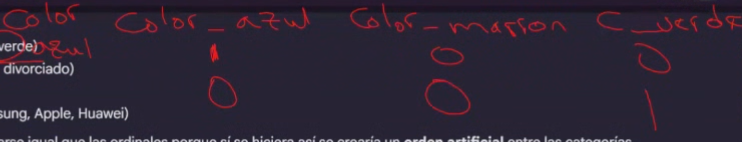

Cuando hay relación entre variables se les llama colineales y si no independientes

Lo ideal es eliminar redundancia, por ejemplo el sexo si tengo una columna para M y otra para F, lo ideal sería tener solo una

In [ ]:
df = pd.get_dummies(
    df,
    columns=['race', 'sex'], #variables a codificar
    dtype=int #Codifica como numero entero, porque por defecto es false o true o flotante
    )

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,capital-gain,capital-loss,hours-per-week,native-country,income,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,2174,0,40,United-States,<=50K,0,0,0,0,1,0,1
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,0,0,13,United-States,<=50K,0,0,0,0,1,0,1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,0,0,40,United-States,<=50K,0,0,0,0,1,0,1
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,0,0,40,United-States,<=50K,0,0,1,0,0,0,1
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,0,0,40,Cuba,<=50K,0,0,1,0,0,1,0


`get_dummies` elimina las columnas originales:

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   age                       30162 non-null  int64 
 1   workclass                 30162 non-null  object
 2   fnlwgt                    30162 non-null  int64 
 3   education                 30162 non-null  object
 4   education-num             30162 non-null  int64 
 5   marital-status            30162 non-null  object
 6   occupation                30162 non-null  object
 7   relationship              30162 non-null  object
 8   capital-gain              30162 non-null  int64 
 9   capital-loss              30162 non-null  int64 
 10  hours-per-week            30162 non-null  int64 
 11  native-country            30162 non-null  object
 12  income                    30162 non-null  object
 13  race_ Amer-Indian-Eskimo  30162 non-null  int64 
 14  race_ Asian-Pac-Islander  3

En `Scikit Learn` se puede usar el método `OneHotEncoder` para hacer esto mismo, aunque este da como resultado un *array* de `NumPy`:

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Variables a codificar

df_ohe = df[['workclass', 'education']]

# Se crea transformador
ohe = OneHotEncoder(sparse_output=False)

# Se aplica transformador, se entrena y se usa
var_ohe = ohe.fit_transform(df_ohe)
print(var_ohe)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [41]:
print(var_ohe.shape)

(30162, 23)


Sin embargo, con el método `get_feature_names_out` es posible obtener el nombre de las variables codificadas:

In [ ]:
names = ohe.get_feature_names_out()
print(names)

#Crea el nombre de la variable y la categoria, por ejemplo: workclass_ Private, education_ Bachelors, etc.

['workclass_ Federal-gov' 'workclass_ Local-gov' 'workclass_ Private'
 'workclass_ Self-emp-inc' 'workclass_ Self-emp-not-inc'
 'workclass_ State-gov' 'workclass_ Without-pay' 'education_ 10th'
 'education_ 11th' 'education_ 12th' 'education_ 1st-4th'
 'education_ 5th-6th' 'education_ 7th-8th' 'education_ 9th'
 'education_ Assoc-acdm' 'education_ Assoc-voc' 'education_ Bachelors'
 'education_ Doctorate' 'education_ HS-grad' 'education_ Masters'
 'education_ Preschool' 'education_ Prof-school' 'education_ Some-college']


In [43]:
print(len(names))

23


En esta codificación siempre va a haber una columna redundante y se crea colinealidad entre variables, porque la información que esta columna redundante contiene se puede inferir de la información de las otras. Este inconveniente se puede solventar con el parámetro `drop_first`.

In [44]:
print(df.relationship.unique())

[' Not-in-family' ' Husband' ' Wife' ' Own-child' ' Unmarried'
 ' Other-relative']


In [45]:
df_rel = df[['relationship']]

df_rel = pd.get_dummies(
    df_rel,
    drop_first=False,
    dtype=int
    )

df_rel.head()

,relationship_ Husband,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife
0,0,1,0,0,0,0
1,1,0,0,0,0,0
2,0,1,0,0,0,0
3,1,0,0,0,0,0
4,0,0,0,0,0,1


relationship_Husband pasa a hacer una categoría implicita con lo de abajo

In [46]:
df_rel = df[['relationship']]

df_rel = pd.get_dummies(
    df_rel,
    drop_first=True,
    dtype=int
    )

df_rel.head()

,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife
0,1,0,0,0,0
1,0,0,0,0,0
2,1,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,1


O con el parámetro `drop` en `OneHotEncoder`.

In [47]:
df_rel = df[['relationship']]

ohe = OneHotEncoder(
    sparse_output=False,
    drop='first'
    )

rel = ohe.fit_transform(df_rel)

columns = ohe.get_feature_names_out()

df_rel_cod = pd.DataFrame(
    data = rel,
    columns = columns
    )

df_rel_cod.head()

,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife
0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0


El problema con eliminar una columna es que se pierde el nombre de la categoría, y esto puede hacer la interpretación del modelo algo más confusa, por lo que se recomienda hacer esto solo con variables **binarias**, usando `drop = 'if_binary'`.

In [48]:
df_rel = df[['relationship']]

ohe = OneHotEncoder(
    sparse_output=False,
    drop='if_binary' #Acá dice que elimine solo si la variable es binaria, es decir, si tiene solo 2 categorías, entonces elimina una de las categorías
    )

rel = ohe.fit_transform(df_rel)

columns = ohe.get_feature_names_out()

df_rel_cod = pd.DataFrame(
    data = rel,
    columns = columns
    )

df_rel_cod.head()

,relationship_ Husband,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife
0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0


In [52]:
df_rel = df[['income']]

ohe = OneHotEncoder(
    sparse_output=False,
    drop='if_binary' #Acá dice que elimine solo si la variable es binaria, es decir, si tiene solo 2 categorías, entonces elimina una de las categorías
    )

inc = ohe.fit_transform(df_rel)

columns = ohe.get_feature_names_out()

df_rel_cod = pd.DataFrame(
    data = inc,
    columns = columns
    )

df_rel_cod.head()

,income_ >50K
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


# Codificación de variables de alta cardinalidad

Las variables cualitativas de alta cardinalidad, es decir, aquellas que tienen una gran cantidad de valores únicos (como códigos postales, nombres de productos, identificadores de cliente, etc.), representan un desafío particular en el preprocesamiento de datos.

Aplicar One-Hot Encoding directamente a una variable de alta cardinalidad es una mala idea por varias razones:

- La maldición de la dimensionalidad maldita: Se crearían cientos o miles de nuevas columnas, lo que aumentaría drásticamente la dimensionalidad del dataset. Esto puede ralentizar el entrenamiento del modelo, consumir una gran cantidad de memoria y, en algunos casos, hacer que el modelo sea menos interpretable y generalizable.
- Distribución dispersa: La mayoría de las nuevas columnas tendrían valores de cero en casi todas las filas, lo que resulta en una matriz de datos muy dispersa (*sparse matrix*) que puede ser ineficiente para algunos algoritmos.

Una forma de abordar este problema es haciendo combinación de categorías (*Binning*). Por ejemplo, si las categorías tienen una distribución de frecuencia muy sesgada (algunas muy frecuentes y la mayoría muy raras), se pueden agrupar las categorías menos frecuentes en una única categoría.

Es posible hacer *binning* tanto en `OrdinalEncoder` como en `OneHotEncoder`.

Se va a ejemplificar su uso con la variable **native-country**:

In [53]:
df['native-country'].value_counts().sort_values(ascending=False)

native-country
United-States                 27504
Mexico                          610
Philippines                     188
Germany                         128
Puerto-Rico                     109
Canada                          107
El-Salvador                     100
India                           100
Cuba                             92
England                          86
Jamaica                          80
South                            71
Italy                            68
China                            68
Dominican-Republic               67
Vietnam                          64
Guatemala                        63
Japan                            59
Columbia                         56
Poland                           56
Haiti                            42
Iran                             42
Taiwan                           42
Portugal                         34
Nicaragua                        33
Peru                             30
Greece                           29
France       

Esta variable es nominal, así que debería codificarse mediante la técnica **One-Hot**, pero esto implicaría crear 41 nuevas columnas (*características*). Se puede limitar el número de columnas creadas usando **binning**.

Lo podemos hacer de 2 maneras, bien sea limtando el número máximo de columnas a crear:

El críterio es la frecuencia relativa, de mayor a menor. Ej: 5 con mayor frecuencia columnas y 6 columna tendrá todos los demás que tienen menos registros

El transformador es el que guarda las categorias codificadas

In [59]:
df_country = df[['native-country']]

ohe = OneHotEncoder(
    sparse_output=False,
    max_categories=6 # Limita a 6 categorías
    #min_frequency=100 #Muestra solo categorías que tengan al menos 100 registros
    )

country_cod = ohe.fit_transform(df_country)

df_country_cod = pd.DataFrame(
    data=country_cod,
    columns=ohe.get_feature_names_out(),
    index=df.index
    )

df_country_cod

,native-country_ Germany,native-country_ Mexico,native-country_ Philippines,native-country_ Puerto-Rico,native-country_ United-States,native-country_infrequent_sklearn
0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...
32556,0.0,0.0,0.0,0.0,1.0,0.0
32557,0.0,0.0,0.0,0.0,1.0,0.0
32558,0.0,0.0,0.0,0.0,1.0,0.0
32559,0.0,0.0,0.0,0.0,1.0,0.0


In [60]:
ohe.infrequent_categories_

[array([' Cambodia', ' Canada', ' China', ' Columbia', ' Cuba',
        ' Dominican-Republic', ' Ecuador', ' El-Salvador', ' England',
        ' France', ' Greece', ' Guatemala', ' Haiti',
        ' Holand-Netherlands', ' Honduras', ' Hong', ' Hungary', ' India',
        ' Iran', ' Ireland', ' Italy', ' Jamaica', ' Japan', ' Laos',
        ' Nicaragua', ' Outlying-US(Guam-USVI-etc)', ' Peru', ' Poland',
        ' Portugal', ' Scotland', ' South', ' Taiwan', ' Thailand',
        ' Trinadad&Tobago', ' Vietnam', ' Yugoslavia'], dtype=object)]

O limitando el número de columnas por una frecuencia relativa mínima:

In [61]:
df_country = df[['native-country']]

ohe = OneHotEncoder(
    sparse_output=False,
    #max_categories=6, # Limita a 6 categorías
    min_frequency=100 # Limita a países con al menos 100 muestras
    )

country_cod = ohe.fit_transform(df_country)

df_country_cod = pd.DataFrame(
    data=country_cod,
    columns=ohe.get_feature_names_out(),
    index=df.index
    )

df_country_cod

,native-country_ Canada,native-country_ El-Salvador,native-country_ Germany,native-country_ India,native-country_ Mexico,native-country_ Philippines,native-country_ Puerto-Rico,native-country_ United-States,native-country_infrequent_sklearn
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
32556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
32557,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
32558,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
32559,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Las categorías que quedaron agrupadas bajo la nueva categoría de infrecuentes se puede ver así:

In [62]:
print(ohe.infrequent_categories_[0])

[' Cambodia' ' China' ' Columbia' ' Cuba' ' Dominican-Republic' ' Ecuador'
 ' England' ' France' ' Greece' ' Guatemala' ' Haiti'
 ' Holand-Netherlands' ' Honduras' ' Hong' ' Hungary' ' Iran' ' Ireland'
 ' Italy' ' Jamaica' ' Japan' ' Laos' ' Nicaragua'
 ' Outlying-US(Guam-USVI-etc)' ' Peru' ' Poland' ' Portugal' ' Scotland'
 ' South' ' Taiwan' ' Thailand' ' Trinadad&Tobago' ' Vietnam'
 ' Yugoslavia']


Con `OrdinalEncoder` también se puede limitar el número de categorías:

In [63]:
orden = [' Never-married', ' Married-civ-spouse', ' Divorced', ' Married-spouse-absent', ' Separated', ' Married-AF-spouse', ' Widowed']

oe = OrdinalEncoder(
    categories=[orden],
    dtype='int',
    max_categories=3
    )

df['marital-satus-ord'] = oe.fit_transform(df[['marital-status']])

df[['marital-status', 'marital-satus-ord']].head(10)

,marital-status,marital-satus-ord
0,Never-married,0
1,Married-civ-spouse,1
2,Divorced,2
3,Married-civ-spouse,1
4,Married-civ-spouse,1
5,Married-civ-spouse,1
6,Married-spouse-absent,2
7,Married-civ-spouse,1
8,Never-married,0
9,Married-civ-spouse,1


In [64]:
print(oe.infrequent_categories_[0])

[' Divorced' ' Married-spouse-absent' ' Separated' ' Married-AF-spouse'
 ' Widowed']


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   age                       30162 non-null  int64 
 1   workclass                 30162 non-null  object
 2   fnlwgt                    30162 non-null  int64 
 3   education                 30162 non-null  object
 4   education-num             30162 non-null  int64 
 5   marital-status            30162 non-null  object
 6   occupation                30162 non-null  object
 7   relationship              30162 non-null  object
 8   capital-gain              30162 non-null  int64 
 9   capital-loss              30162 non-null  int64 
 10  hours-per-week            30162 non-null  int64 
 11  native-country            30162 non-null  object
 12  income                    30162 non-null  object
 13  race_ Amer-Indian-Eskimo  30162 non-null  int64 
 14  race_ Asian-Pac-Islander  3

## Target encoding

Otro método de codificación que se ha empezado a volver popular es **Target Encoding**. En este método cada categoría se reemplaza con la **media de la variable objetivo para esa categoría**. Por poner un ejemplo, si la variable objetivo es **income**, cada categoría de la variable **education** se codificaría con la proporción de registros que pertenecen a cada categoría de **income**.

In [66]:
from sklearn.preprocessing import TargetEncoder

te = TargetEncoder()

df['education-te'] = te.fit_transform(
    X = df[['education']],
    y = df['income']
    )

df[['education', 'education-te', 'income']].head(10)

,education,education-te,income
0,Bachelors,0.420357,<=50K
1,Bachelors,0.423240,<=50K
2,HS-grad,0.166801,<=50K
3,11th,0.063720,<=50K
4,Bachelors,0.419959,<=50K
5,Masters,0.561739,<=50K
6,9th,0.060932,<=50K
7,HS-grad,0.163432,>50K
8,Masters,0.567683,>50K
9,Bachelors,0.423240,>50K


In [ ]:
pd.crosstab(
    index = df['education'],
    columns = df['income'],
    normalize = 'index'
)

#Analiza que proporcion hay en la variable objetivo para cada categoría de la variable educación, por ejemplo: para la categoría Bachelors, el 70% tiene un ingreso menor a 50K y el 30% tiene un ingreso mayor a 50K.

income,<=50K,>50K
education,,
10th,0.928049,0.071951
11th,0.943702,0.056298
12th,0.923077,0.076923
1st-4th,0.960265,0.039735
5th-6th,0.958333,0.041667
7th-8th,0.937163,0.062837
9th,0.945055,0.054945
Assoc-acdm,0.746032,0.253968
Assoc-voc,0.736802,0.263198


Esta técnica es muy efectiva porque codifica la variable directamente con información predictiva. Reduce la dimensionalidad, ya que no genera columnas adicionales, y a menudo mejora el rendimiento del modelo. Sin embargo, es propensa al sobreajuste si se usa sin las precauciones adecuadas, especialmente en categorías con pocas observaciones. Para mitigar esto, se suelen usar técnicas como el suavizado (*smoothing*), donde se promedian las medias de las categorías raras con la media global de la variable objetivo. También es crucial aplicar esta codificación solo en el conjunto de entrenamiento y luego usar las medias calculadas para transformar los conjuntos de validación y prueba.

# Ejercicio

Codifique las variables categóricas preseleccionadas del dataset "Telco_customer_churn.csv".